# 02 - EDA simple

But : comprendre rapidement ce qui se passe dans le business avec des graphiques simples.

Les graphiques s'affichent directement dans le notebook.


## 1. Importer le fichier clean

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "data_cleaned_final.xlsx"

transactions = pd.read_excel(file_path, sheet_name="Carnet_transactions", dtype={"Code client": str})
clients = pd.read_excel(file_path, sheet_name="Carnet_client", dtype={"Code Client": str})

clients = clients.rename(columns={"Code Client": "Code client"})

transactions["Date"] = pd.to_datetime(transactions["Date"])
transactions["Revenue"] = pd.to_numeric(transactions["Revenue"], errors="coerce")

transactions["Year"] = transactions["Date"].dt.year
transactions["Month"] = transactions["Date"].dt.to_period("M").astype(str)

data = transactions.merge(
    clients[["Code client", "Activité"]],
    on="Code client",
    how="left"
)

data["Activité"] = data["Activité"].fillna("Activité inconnue")

print("Données prêtes :", data.shape)
display(data.head())

Données prêtes : (127664, 9)


,Code client,Produit,Date,Revenue,Client_id_valide,Revenue_negatif,Year,Month,Activité
0,041760,P1,2021-03-01,154.301667,True,False,2021,2021-03,Activité 1
1,006064,P1,2018-07-01,333.130000,True,False,2018,2018-07,Activité 1
2,012002,P2,2021-04-01,456.940000,True,False,2021,2021-04,Activité 1
3,000300,P3,2020-06-01,188.199000,True,False,2020,2020-06,Activité 1
4,002498,P1,2021-02-01,304.060000,True,False,2021,2021-02,Activité 1


## 2. Quelques chiffres rapides

In [2]:
revenu_total = data["Revenue"].sum()
nb_clients = data["Code client"].nunique()
nb_transactions = len(data)

print("Revenu total :", round(revenu_total, 2))
print("Nombre de clients :", nb_clients)
print("Nombre de transactions :", nb_transactions)
print("Période :", data["Date"].min(), "à", data["Date"].max())

Revenu total : 58798770.43
Nombre de clients : 3542
Nombre de transactions : 127664
Période : 2018-01-01 00:00:00 à 2021-12-01 00:00:00


## 3. Le revenu évolue comment ?

Year
2018    1.418892e+07
2019    1.423547e+07
2020    1.423970e+07
2021    1.613468e+07
Name: Revenue, dtype: float64

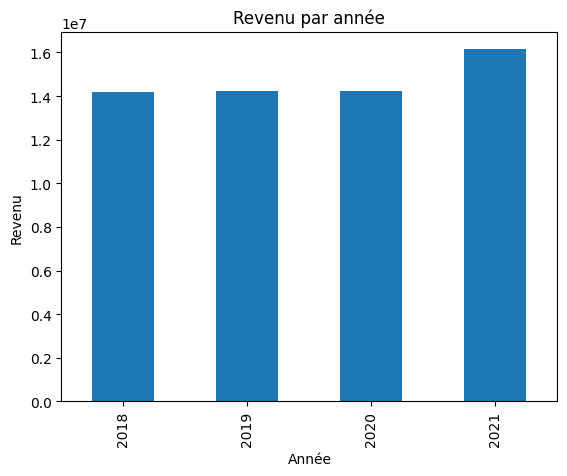

In [3]:
revenu_par_annee = data.groupby("Year")["Revenue"].sum()

display(revenu_par_annee)

revenu_par_annee.plot(kind="bar")
plt.title("Revenu par année")
plt.xlabel("Année")
plt.ylabel("Revenu")
plt.show()

## 4. Quel produit rapporte le plus ?

Produit
P1    3.355896e+07
P2    1.807764e+07
P3    7.162175e+06
Name: Revenue, dtype: float64

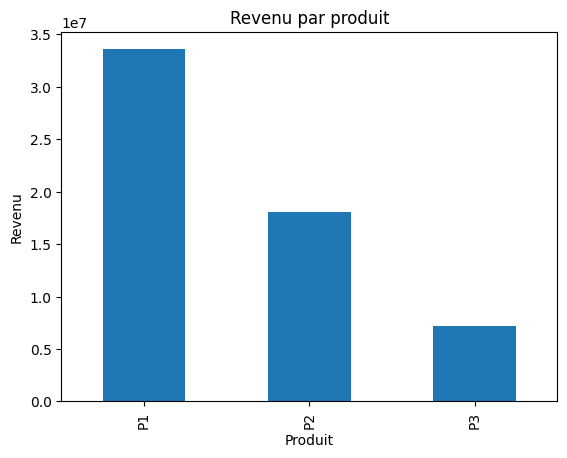

In [4]:
revenu_par_produit = data.groupby("Produit")["Revenue"].sum().sort_values(ascending=False)

display(revenu_par_produit)

revenu_par_produit.plot(kind="bar")
plt.title("Revenu par produit")
plt.xlabel("Produit")
plt.ylabel("Revenu")
plt.show()

## 5. Les produits changent comment dans le temps ?

Produit,P1,P2,P3
Year,,,
2018,9.273733e+06,4.646793e+06,2.683950e+05
2019,8.209870e+06,4.567151e+06,1.458447e+06
2020,7.727139e+06,4.026202e+06,2.486361e+06
2021,8.348217e+06,4.837490e+06,2.948973e+06


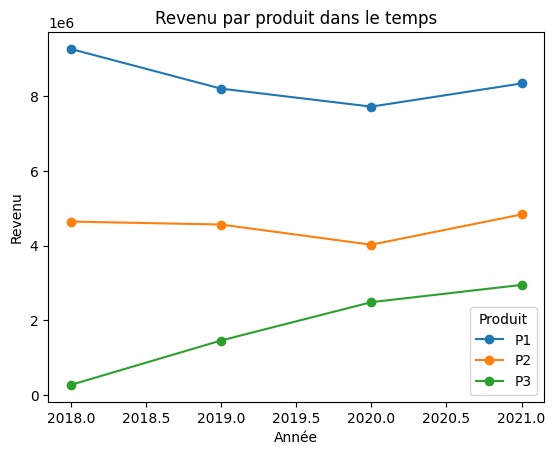

In [5]:
produit_annee = data.groupby(["Year", "Produit"])["Revenue"].sum().unstack()

display(produit_annee)

produit_annee.plot(kind="line", marker="o")
plt.title("Revenu par produit dans le temps")
plt.xlabel("Année")
plt.ylabel("Revenu")
plt.show()

## 6. P3 prend-il plus de place ?

Year
2018     1.89
2019    10.25
2020    17.46
2021    18.28
dtype: float64

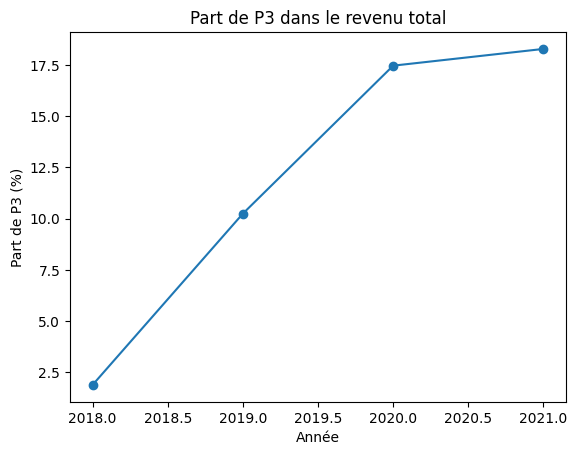

In [6]:
part_p3 = produit_annee["P3"] / produit_annee.sum(axis=1) * 100

display(part_p3.round(2))

part_p3.plot(kind="line", marker="o")
plt.title("Part de P3 dans le revenu total")
plt.xlabel("Année")
plt.ylabel("Part de P3 (%)")
plt.show()

## 7. Quelle activité rapporte le plus ?

Activité
Activité 1    2.145448e+07
Activité 3    2.055814e+07
Activité 2    1.330820e+07
Name: Revenue, dtype: float64

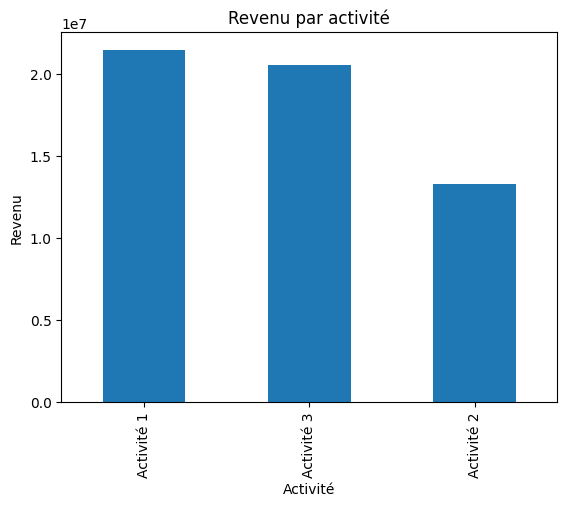

In [7]:
# Ici on garde seulement les vraies activités
data_activite = data[data["Activité"].isin(["Activité 1", "Activité 2", "Activité 3"])]

revenu_par_activite = data_activite.groupby("Activité")["Revenue"].sum().sort_values(ascending=False)

display(revenu_par_activite)

revenu_par_activite.plot(kind="bar")
plt.title("Revenu par activité")
plt.xlabel("Activité")
plt.ylabel("Revenu")
plt.show()

## 8. Quelle activité rapporte le plus par client ?

,Revenu,Clients,Revenu par client
Activité,,,
Activité 1,2.145448e+07,3298,6505.299803
Activité 2,1.330820e+07,28,475292.952489
Activité 3,2.055814e+07,215,95619.275214


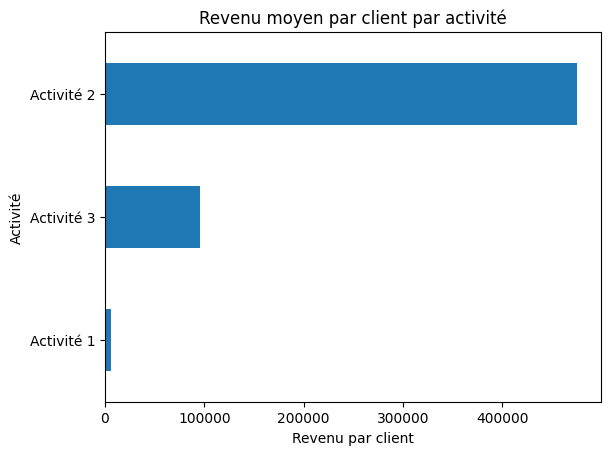

In [8]:
resume_activite = data_activite.groupby("Activité").agg(
    Revenu=("Revenue", "sum"),
    Clients=("Code client", "nunique")
)

resume_activite["Revenu par client"] = resume_activite["Revenu"] / resume_activite["Clients"]

display(resume_activite)

resume_activite["Revenu par client"].sort_values().plot(kind="barh")
plt.title("Revenu moyen par client par activité")
plt.xlabel("Revenu par client")
plt.ylabel("Activité")
plt.show()

## 9. Est-ce que le business dépend de quelques gros clients ?

Code client
012749    3.477945e+06
005183    1.954299e+06
010615    1.841928e+06
012780    1.474083e+06
041969    1.429802e+06
009950    1.263386e+06
011865    1.093917e+06
001592    1.086936e+06
010114    1.054996e+06
010453    1.010609e+06
Name: Revenue, dtype: float64

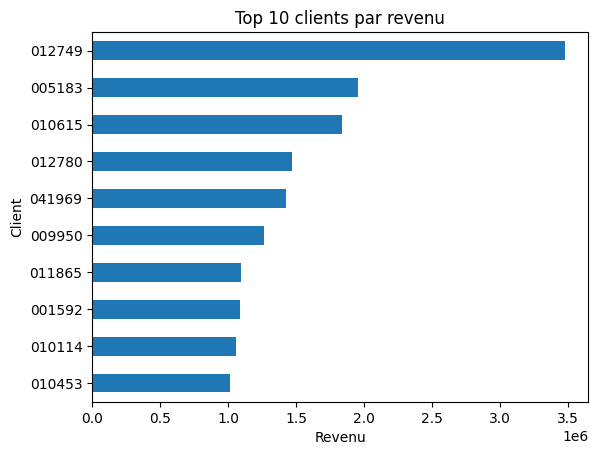

Part des 10 plus gros clients : 26.68 %


In [9]:
revenu_client = data.groupby("Code client")["Revenue"].sum().sort_values(ascending=False)

top_10 = revenu_client.head(10)

display(top_10)

top_10.sort_values().plot(kind="barh")
plt.title("Top 10 clients par revenu")
plt.xlabel("Revenu")
plt.ylabel("Client")
plt.show()

part_top_10 = top_10.sum() / revenu_client.sum() * 100
print("Part des 10 plus gros clients :", round(part_top_10, 2), "%")

## 10. Les clients sont-ils récurrents ?

Moyenne de mois actifs : 31.82
Clients actifs 48 mois : 1503


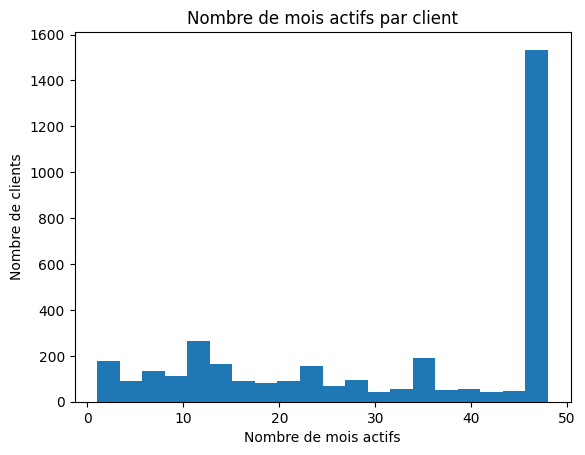

In [10]:
mois_actifs = data.groupby("Code client")["Month"].nunique()

print("Moyenne de mois actifs :", round(mois_actifs.mean(), 2))
print("Clients actifs 48 mois :", (mois_actifs == 48).sum())

mois_actifs.plot(kind="hist", bins=20)
plt.title("Nombre de mois actifs par client")
plt.xlabel("Nombre de mois actifs")
plt.ylabel("Nombre de clients")
plt.show()

## 11. Revenus négatifs

Nombre de transactions négatives : 136
Total revenu négatif : -20949.92


Produit
P3   -14477.270688
P1    -5728.026584
P2     -744.620000
Name: Revenue, dtype: float64

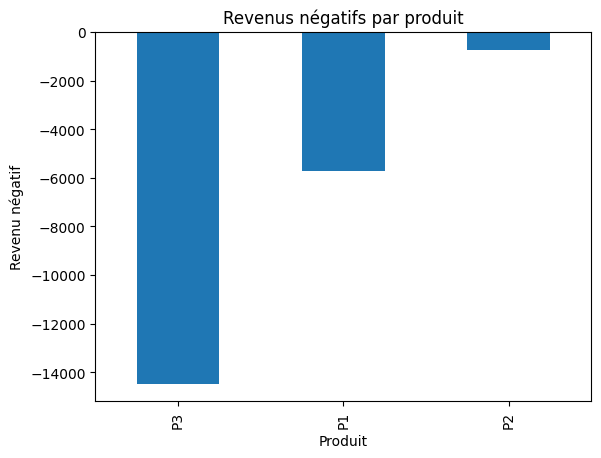

In [11]:
revenus_negatifs = data[data["Revenue"] < 0]

print("Nombre de transactions négatives :", len(revenus_negatifs))
print("Total revenu négatif :", round(revenus_negatifs["Revenue"].sum(), 2))

negatif_par_produit = revenus_negatifs.groupby("Produit")["Revenue"].sum().sort_values()

display(negatif_par_produit)

negatif_par_produit.plot(kind="bar")
plt.title("Revenus négatifs par produit")
plt.xlabel("Produit")
plt.ylabel("Revenu négatif")
plt.show()

## 12. Conclusion 

In [ ]:
print("Conclusion ")
print("- Le revenu est stable entre 2018 et 2020, puis augmente en 2021.")
print("- P1 est le produit principal en revenu.")
print("- P3 est plus petit, mais il grandit vite.")
print("- Activité 1 rapporte le plus au total.")
print("- Activité 2 rapporte plus par client.")
print("- Une partie importante du revenu vient des gros clients.")
print("- Les revenus négatifs doivent être clarifiés : refunds, avoirs ou annulations possibles.")

Conclusions simples :
- Le revenu est stable entre 2018 et 2020, puis augmente en 2021.
- P1 est le produit principal en revenu.
- P3 est plus petit, mais il grandit vite.
- Activité 1 rapporte le plus au total.
- Activité 2 rapporte plus par client.
- Une partie importante du revenu vient des gros clients.
- Les revenus négatifs doivent être clarifiés : refunds, avoirs ou annulations possibles.
